# 🚧 [DEPRECATED] Exploration Initiale — Classification par Score Total
# 🚧 [DEPRECATED] Initial Exploration — Total Score-Based Classification

---

**🇫🇷 Note de dépréciation :**  
Ce notebook constitue la phase d'exploration initiale du projet. Il a permis de valider l'existence de groupes comportementaux distincts dans la base d'utilisateurs AtCoder et de poser les premières hypothèses de segmentation. Cependant, sa méthode de classification — fondée sur le **score total cumulé** — présente deux limites fondamentales :
1. Les scores ne sont pas comparables entre les différents types de contests AtCoder (ABC, AGC, ARC, contests sponsors).
2. Les seuils de classification (1 000 / 5 000 pts) sont définis de manière arbitraire et ne reposent sur aucune méthodologie validée.

**Ce notebook est conservé à titre d'historique de recherche.** La classification finale du projet s'appuie sur la méthodologie de Shimizu *et al.* (2025) : lettre de difficulté maximale résolue (A–F) dans les AtCoder Beginner Contests uniquement.

---

**🇬🇧 Deprecation notice:**  
This notebook represents the initial exploratory phase of the project. It successfully validated the existence of distinct behavioral groups within the AtCoder user base and established preliminary segmentation hypotheses. However, its classification method — based on **cumulative total score** — has two fundamental limitations:
1. Scores are not comparable across different AtCoder contest types (ABC, AGC, ARC, sponsor contests).
2. The classification thresholds (1,000 / 5,000 pts) are defined arbitrarily and are not grounded in a validated methodology.

**This notebook is preserved as a research history record.** The project's final classification follows the methodology of Shimizu *et al.* (2025): maximum solved difficulty letter (A–F) within AtCoder Beginner Contests only.

---
➡️ **Voir / See:** `src/difficulty_labeler.py` — Classification finale A–F


---
## Section 1 — Aperçu Global du Dataset / Global Dataset Overview
---


In [1]:
import polars as pl

# Chargement de la liste globale des problèmes / Load global problem list
df_problems = pl.read_csv('../data/Project_CodeNet/metadata/problem_list.csv')
print(f'Problèmes uniques / Unique problems: {df_problems.shape[0]:,}')
print('\nAperçu / Overview:')
display(df_problems.head())

# Scan paresseux de toutes les soumissions / Lazy scan of all submissions
lazy_submissions = pl.scan_csv('../data/Project_CodeNet/metadata/p[0-9]*.csv')

print('\nComptage des soumissions / Counting total submissions...')
total_submissions = lazy_submissions.select(pl.len()).collect().item()
print(f'Total soumissions / Total submissions: {total_submissions:,}')

print('\nAperçu des colonnes disponibles / Available columns:')
display(lazy_submissions.head().collect())


Problèmes uniques / Unique problems: 4,053

Aperçu / Overview:


id,name,dataset,time_limit,memory_limit,rating,tags,complexity
str,str,str,i64,i64,str,str,str
"""p00000""","""QQ""","""AIZU""",1000,131072,null,null,null
"""p00001""","""List of Top 3 Hills""","""AIZU""",1000,131072,null,null,null
"""p00002""","""Digit Number""","""AIZU""",1000,131072,null,null,null
"""p00003""","""Is it a Right Triangle?""","""AIZU""",1000,131072,null,null,null
"""p00004""","""Simultaneous Equation""","""AIZU""",1000,131072,null,null,null



Comptage des soumissions / Counting total submissions...
Total soumissions / Total submissions: 13,916,868

Aperçu des colonnes disponibles / Available columns:


submission_id,problem_id,user_id,date,language,original_language,filename_ext,status,cpu_time,memory,code_size,accuracy
str,str,str,str,str,str,str,str,str,str,str,str
"""s694813024""","""p00000""","""u706566315""","""1540908251""","""Rust""","""Rust""","""rs""","""Wrong Answer""","""0""","""5012""","""120""","""0/1"""
"""s554950692""","""p00000""","""u706566315""","""1540908314""","""Rust""","""Rust""","""rs""","""Accepted""","""0""","""5004""","""124""","""1/1"""
"""s555203498""","""p00000""","""u759934006""","""1513417513""","""Rust""","""Rust""","""rs""","""Accepted""","""0""","""5020""","""136""","""1/1"""
"""s309783173""","""p00000""","""u233505136""","""1516826051""","""Rust""","""Rust""","""rs""","""Accepted""","""0""","""5004""","""123""","""1/1"""
"""s184977351""","""p00000""","""u191088660""","""1517740150""","""Rust""","""Rust""","""rs""","""Accepted""","""0""","""5004""","""122""","""1/1"""


### Observations

**🇫🇷** Le dataset Project CodeNet couvre **4 053 problèmes** issus de deux plateformes (AtCoder et AIZU), avec près de **14 millions de soumissions** au total. Chaque soumission enregistre : l'identifiant de soumission, l'utilisateur, la date, le langage de programmation, le statut du juge (*Accepted*, *Wrong Answer*, etc.), le temps CPU, la mémoire utilisée et la taille du code. Ces métadonnées constituent la matière première de l'ensemble de l'analyse.

**🇬🇧** The Project CodeNet dataset covers **4,053 problems** from two platforms (AtCoder and AIZU), with nearly **14 million submissions** in total. Each submission records: submission ID, user ID, date, programming language, judge status (*Accepted*, *Wrong Answer*, etc.), CPU time, memory usage, and code size. These metadata form the raw material for the entire analysis.


In [2]:
print('Distribution des langages / Programming language distribution...')

language_distribution = (
    lazy_submissions
    .group_by('language')
    .agg(pl.len().alias('submission_count'))
    .sort('submission_count', descending=True)
    .collect()
)

print('Top 10 langages / Top 10 programming languages:')
display(language_distribution.head(10))


Distribution des langages / Programming language distribution...
Top 10 langages / Top 10 programming languages:


language,submission_count
str,u32
"""C++""",8008527
"""Python""",3286314
"""C""",754058
"""Java""",712153
"""Ruby""",250403
"""C#""",235107
"""Rust""",127210
"""Go""",99125
"""JavaScript""",58395


### Distribution des Langages / Language Distribution

**🇫🇷** Le C++ domine très largement avec environ **58 % des soumissions**, suivi de Python (~24 %) et C (~5 %). Cette répartition est caractéristique de la programmation compétitive, où le C++ est privilégié pour ses performances d'exécution. Conformément à la méthodologie de Shimizu *et al.* (2025), cette étude ne segmente pas l'analyse par langage de programmation — une analyse différenciée par langage est identifiée comme une perspective de recherche future.

**🇬🇧** C++ dominates with approximately **58% of submissions**, followed by Python (~24%) and C (~5%). This distribution is characteristic of competitive programming, where C++ is favored for execution performance. In line with Shimizu *et al.* (2025), this study does not segment analysis by programming language — language-specific analysis is identified as future research.


---
## Section 2 — Profilage des Utilisateurs par Score Total (Approche Exploratoire)
## Section 2 — User Profiling by Total Score (Exploratory Approach)
---


In [3]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

print('Chargement des profils utilisateurs / Loading user profiles...')
df_users = pl.read_csv('../data/processed/atcoder_user_profiles.csv')

# Suppression des profils fantômes (< 3 problèmes tentés)
# Removal of ghost profiles (< 3 problems attempted)
df_clean = df_users.filter(pl.col('unique_problems_attempted') >= 3)

dropped = df_users.shape[0] - df_clean.shape[0]
print(f'Profils supprimés / Removed profiles: {dropped:,}')
print(f'Profils actifs retenus / Active profiles kept: {df_clean.shape[0]:,}')

print('\nStatistiques du score total / Total score statistics:')
display(df_clean.select('total_true_score').describe())


Chargement des profils utilisateurs / Loading user profiles...
Profils supprimés / Removed profiles: 25,971
Profils actifs retenus / Active profiles kept: 97,672

Statistiques du score total / Total score statistics:


statistic,total_true_score
str,f64
"""count""",97672.0
"""null_count""",0.0
"""mean""",14763.770815
"""std""",37670.759684
"""min""",0.0
"""25%""",900.0
"""50%""",2700.0
"""75%""",10300.0
"""max""",733743.0


### Filtrage des Profils Inactifs / Inactive Profile Filtering

**🇫🇷** La suppression des utilisateurs ayant effectué moins de 3 tentatives — critère adopté par Shimizu *et al.* (2025) — élimine **25 971 profils** insuffisants pour une analyse comportementale. Les **97 672 profils actifs** retenus présentent une distribution fortement asymétrique vers la droite : la médiane (~2 700 pts) est très inférieure à la moyenne (~14 764 pts), et le score maximum atteint 733 743 pts. Cette dispersion extrême confirme l'hétérogénéité marquée du niveau des utilisateurs dans la base AtCoder.

**🇬🇧** Removing users with fewer than 3 attempts — following the criterion of Shimizu *et al.* (2025) — eliminates **25,971 profiles** insufficient for behavioral analysis. The **97,672 active profiles** retained exhibit a strongly right-skewed distribution: the median (~2,700 pts) is well below the mean (~14,764 pts), and the maximum score reaches 733,743 pts. This extreme dispersion confirms the marked heterogeneity of skill levels across the AtCoder user base.


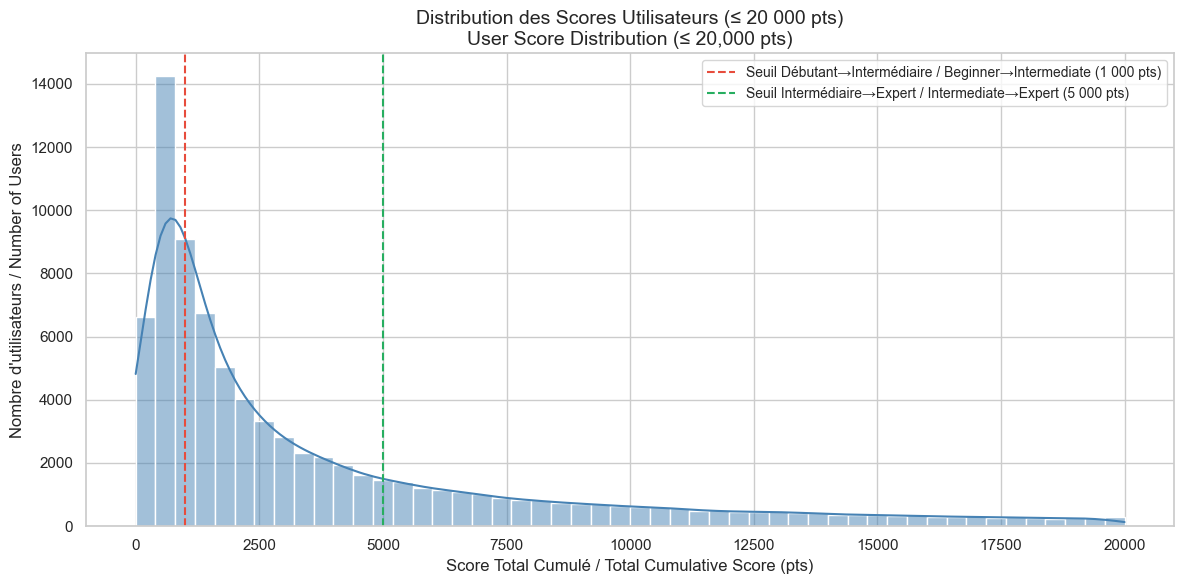

In [4]:
plt.figure(figsize=(12, 6))

plot_data = df_clean.filter(pl.col('total_true_score') <= 20000).to_pandas()

sns.histplot(data=plot_data, x='total_true_score', bins=50, kde=True, color='steelblue')
plt.title(
    'Distribution des Scores Utilisateurs (≤ 20 000 pts)\nUser Score Distribution (≤ 20,000 pts)',
    fontsize=14
)
plt.xlabel('Score Total Cumulé / Total Cumulative Score (pts)', fontsize=12)
plt.ylabel("Nombre d'utilisateurs / Number of Users", fontsize=12)
plt.axvline(x=1000, color='#e74c3c', linestyle='--', linewidth=1.5, label='Seuil Débutant→Intermédiaire / Beginner→Intermediate (1 000 pts)')
plt.axvline(x=5000, color='#27ae60', linestyle='--', linewidth=1.5, label='Seuil Intermédiaire→Expert / Intermediate→Expert (5 000 pts)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


In [5]:
# Classification exploratoire par seuils de score
# Exploratory classification by score thresholds
def categorize_proficiency(score):
    if score < 1000:
        return 'Beginner'
    elif score < 5000:
        return 'Intermediate'
    else:
        return 'Expert'

df_classified = df_clean.with_columns(
    pl.col('total_true_score')
    .map_elements(categorize_proficiency, return_dtype=pl.Utf8)
    .alias('proficiency_level')
)

stats = (
    df_classified
    .group_by('proficiency_level')
    .agg(
        pl.len().alias('user_count'),
        pl.col('total_true_score').mean().round(0).alias('avg_score'),
        pl.col('problem_win_rate').mean().round(3).alias('avg_win_rate'),
    )
    .sort('avg_score')
)

print('Distribution de proficience (approche exploratoire) / Proficiency distribution (exploratory):')
display(stats)

df_classified.write_csv('../data/processed/atcoder_users_classified.csv')
print('\n✅ Sauvegardé / Saved: atcoder_users_classified.csv')


Distribution de proficience (approche exploratoire) / Proficiency distribution (exploratory):


proficiency_level,user_count,avg_score,avg_win_rate
str,u32,f64,f64
"""Beginner""",25355,530.0,0.78
"""Intermediate""",35363,2343.0,0.877
"""Expert""",36954,36416.0,0.921



✅ Sauvegardé / Saved: atcoder_users_classified.csv


### Classification par Seuils — Limites Méthodologiques / Score Threshold Classification — Methodological Limits

**⚠️ 🇫🇷 Limites de cette approche :**  
Les seuils retenus (1 000 et 5 000 pts) sont **définis visuellement** à partir de la distribution observée et n'ont pas de fondement méthodologique rigoureux. De plus, les scores totaux cumulés **ne sont pas comparables entre types de contests** (un problème ABC vaut 100–600 pts, un problème AGC peut valoir 300–2 200 pts). Cette approche est donc conservée uniquement comme exploration initiale.  
L'observation que le taux de victoire (*win rate*) progresse de 78 % (débutants) à 92 % (experts) reste néanmoins une validation comportementale cohérente avec les résultats de Shimizu *et al.* (2025).

**⚠️ 🇬🇧 Limitations of this approach:**  
The chosen thresholds (1,000 and 5,000 pts) are **defined visually** from the observed distribution and lack rigorous methodological grounding. Furthermore, cumulative total scores are **not comparable across contest types** (an ABC problem is worth 100–600 pts, while an AGC problem may be worth 300–2,200 pts). This approach is therefore preserved only as initial exploration.  
The observation that the win rate increases from 78% (beginners) to 92% (experts) nevertheless constitutes a behavioral validation consistent with Shimizu *et al.* (2025).


---
## Section 3 — Clustering Non Supervisé (K-Means + ACP)
## Section 3 — Unsupervised Clustering (K-Means + PCA)
---


Préparation des features / Preparing features...
Profils moyens par cluster / Average profile per cluster:


,unique_problems_attempted,total_true_score,problem_win_rate,submissions_per_problem
Cluster,,,,
0,45.55,10149.13,0.93,1.85
1,12.44,1754.67,0.68,2.73
2,529.01,152374.30,0.97,2.05



Variance expliquée / Explained variance: PC1=51.1%, PC2=27.7%


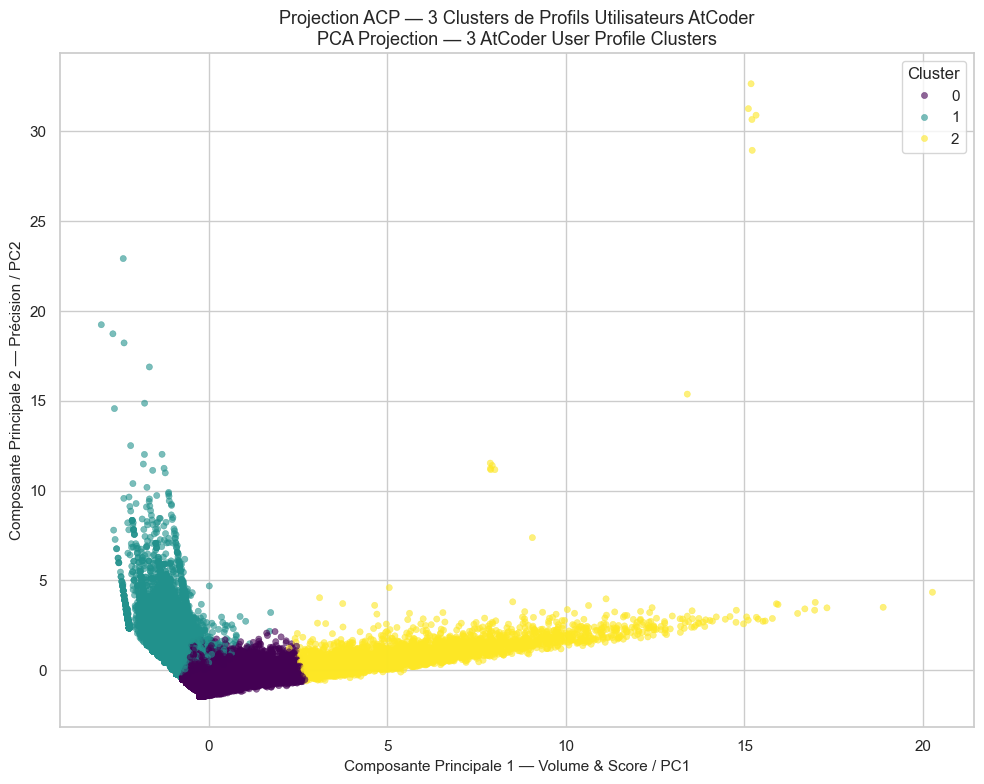

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

print('Préparation des features / Preparing features...')
features = ['unique_problems_attempted', 'total_true_score', 'problem_win_rate', 'submissions_per_problem']
X = df_clean.select(features).to_pandas()

# Standardisation — indispensable pour K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
X['Cluster'] = kmeans.fit_predict(X_scaled)

print('Profils moyens par cluster / Average profile per cluster:')
display(X.groupby('Cluster').mean().round(2))

# ACP 2D pour visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X['PCA_1'] = X_pca[:, 0]
X['PCA_2'] = X_pca[:, 1]

var = pca.explained_variance_ratio_
print(f'\nVariance expliquée / Explained variance: PC1={var[0]:.1%}, PC2={var[1]:.1%}')

plt.figure(figsize=(10, 8))
sns.scatterplot(data=X, x='PCA_1', y='PCA_2', hue='Cluster',
                palette='viridis', alpha=0.6, edgecolor=None, s=20)
plt.title('Projection ACP — 3 Clusters de Profils Utilisateurs AtCoder\nPCA Projection — 3 AtCoder User Profile Clusters', fontsize=13)
plt.xlabel('Composante Principale 1 — Volume & Score / PC1', fontsize=11)
plt.ylabel('Composante Principale 2 — Précision / PC2', fontsize=11)
plt.tight_layout()
plt.show()


Méthode du coude / Elbow method...


/var/folders/98/xwy58m4n6f1c3yc3nsy3vf3c0000gn/T/ipykernel_46878/3926361072.py:11: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(K_range, wcss, 'bo-', color='#3498db', linewidth=2, markersize=8)


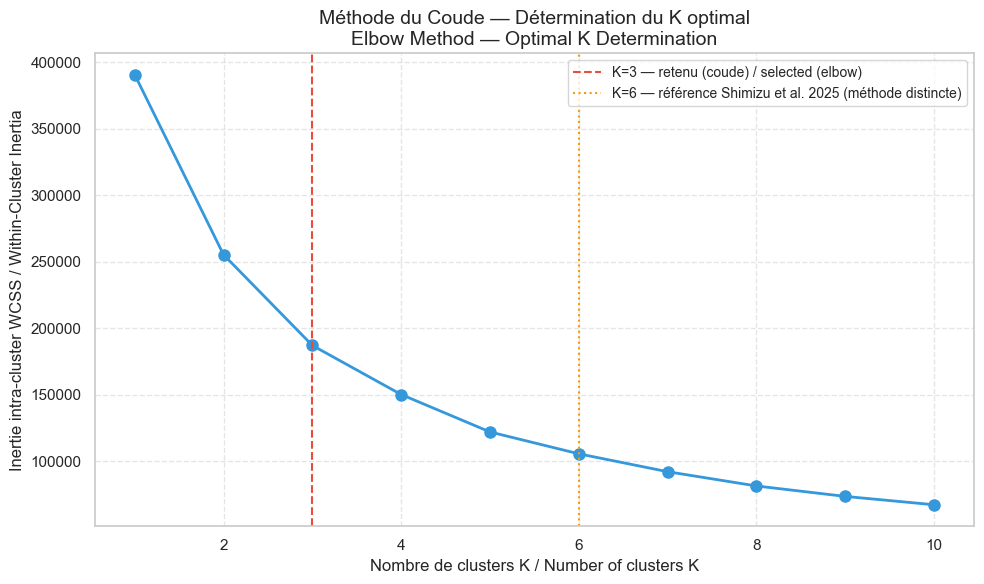

In [7]:
print('Méthode du coude / Elbow method...')

wcss = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, 'bo-', color='#3498db', linewidth=2, markersize=8)
plt.title('Méthode du Coude — Détermination du K optimal\nElbow Method — Optimal K Determination', fontsize=14)
plt.xlabel('Nombre de clusters K / Number of clusters K', fontsize=12)
plt.ylabel('Inertie intra-cluster WCSS / Within-Cluster Inertia', fontsize=12)
plt.axvline(x=3, color='#e74c3c', linestyle='--', linewidth=1.5,
            label='K=3 — retenu (coude) / selected (elbow)')
plt.axvline(x=6, color='#f39c12', linestyle=':', linewidth=1.5,
            label='K=6 — référence Shimizu et al. 2025 (méthode distincte)')
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Méthode du Coude & Choix de K / Elbow Method & K Selection

**🇫🇷** La méthode du coude révèle un point d'inflexion significatif à **K=3**, indiquant que trois clusters constituent la partition la plus naturelle des données comportementales analysées. Ce choix est **justifié par les données elles-mêmes**, et non par un alignement avec Shimizu *et al.* (2025) — qui identifie quant à lui **6 groupes** (G1–G6) via une méthode entièrement différente (lettre de difficulté maximale résolue). Ces deux approches sont donc **indépendantes et complémentaires** : le K-Means explore la structure latente du comportement utilisateur, tandis que la classification de Shimizu repose sur une définition externe du niveau.

**🇬🇧** The Elbow method reveals a significant inflection point at **K=3**, indicating that three clusters form the most natural partition of the behavioral data. This choice is **justified by the data itself**, and not by alignment with Shimizu *et al.* (2025) — who identifies **6 groups** (G1–G6) through an entirely different method (maximum solved difficulty letter). These two approaches are therefore **independent and complementary**: K-Means explores the latent structure of user behavior, while Shimizu's classification relies on an externally defined level criterion.


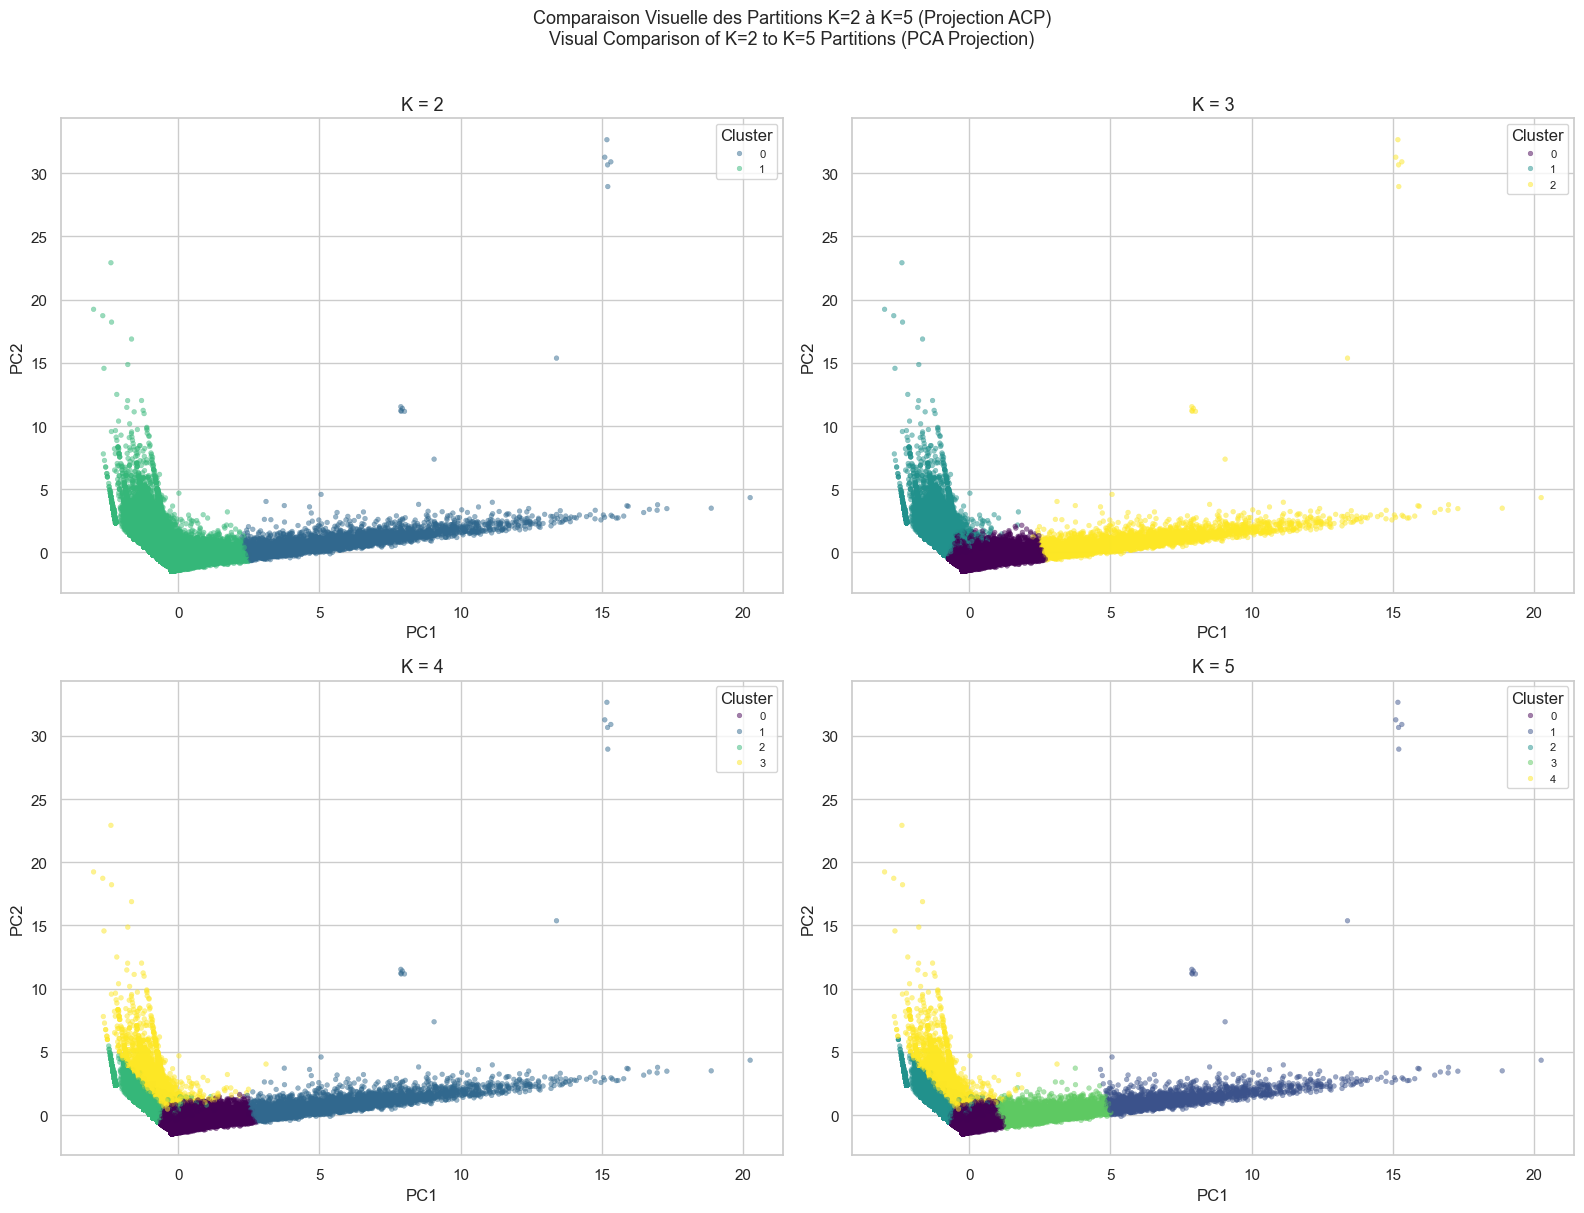

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, k in enumerate([2, 3, 4, 5]):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels,
                    palette='viridis', alpha=0.5, edgecolor=None, s=12, ax=axes[i])
    axes[i].set_title(f'K = {k}', fontsize=13)
    axes[i].set_xlabel('PC1')
    axes[i].set_ylabel('PC2')
    axes[i].legend(title='Cluster', fontsize=8)

plt.suptitle(
    'Comparaison Visuelle des Partitions K=2 à K=5 (Projection ACP)\n'
    'Visual Comparison of K=2 to K=5 Partitions (PCA Projection)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()


### Validation Visuelle des Clusters / Visual Cluster Validation

**🇫🇷** La projection ACP confirme que **K=3 offre la séparation la plus nette et naturelle** des groupes comportementaux. Pour K=4 et K=5, l'algorithme ne découvre pas de nouvelles structures, mais subdivise artificiellement des régions continues. Cette exploration valide l'existence d'au moins trois **dynamiques d'apprentissage distinctes** dans la base AtCoder. Ces résultats constituent un premier argument empirique en faveur d'une segmentation des utilisateurs, qui sera affinée dans la suite du projet par la méthode de classification A–F.

**🇬🇧** The PCA projection confirms that **K=3 provides the clearest and most natural group separation**. For K=4 and K=5, the algorithm reveals no new structures, but artificially subdivides continuous regions. This exploration validates the existence of at least three **distinct learning dynamics** within the AtCoder user base. These results constitute a first empirical argument for user segmentation, which will be refined in the next project phases through the A–F difficulty letter classification.


---
## Section 4 — Analyse des Problèmes AtCoder Beginner Contest (ABC)
## Section 4 — AtCoder Beginner Contest (ABC) Problem Analysis

**🇫🇷** Cette section introduit la labellisation rigoureuse des problèmes par lettre de difficulté (A–F), suivant la méthodologie de Shimizu *et al.* (2025). Seuls les problèmes issus des **AtCoder Beginner Contests** sont retenus. La lettre est assignée par **position ordinale au sein de chaque contest** dans le fichier `problem_list.csv` — les problèmes y étant triés par difficulté croissante.

**🇬🇧** This section introduces the rigorous difficulty letter labeling (A–F), following the methodology of Shimizu *et al.* (2025). Only problems from **AtCoder Beginner Contests** are retained. The letter is assigned by **ordinal position within each contest** in the `problem_list.csv` file — problems being sorted by increasing difficulty therein.

---


In [9]:
from collections import defaultdict
import polars as pl

# Chargement et filtrage ABC uniquement
df_problems = pl.read_csv('../data/Project_CodeNet/metadata/problem_list.csv')
df_abc_raw = df_problems.filter(
    (pl.col('dataset') == 'AtCoder') &
    (pl.col('name').str.starts_with('AtCoder Beginner Contest'))
)

# Assignation A-F par position dans chaque contest
LETTERS = ['A', 'B', 'C', 'D', 'E', 'F']
contest_groups = defaultdict(list)
for row in df_abc_raw.iter_rows(named=True):
    contest = row['name'].rsplit(' - ', 1)[0]
    contest_groups[contest].append(row['id'])

labeled_rows = []
for contest, ids in sorted(contest_groups.items()):
    for i, pid in enumerate(ids):
        if i < len(LETTERS):
            labeled_rows.append({'problem_id': pid, 'contest': contest, 'difficulty': LETTERS[i]})

df_abc = pl.DataFrame(labeled_rows)

# Statistiques générales
sizes = defaultdict(int)
for ids in contest_groups.values():
    sizes[len(ids)] += 1

print(f'Nombre de contests ABC / Total ABC contests: {len(contest_groups)}')
print(f'Nombre total de problèmes ABC / Total ABC problems: {len(labeled_rows)}')
print('\nRépartition par taille de contest / Contest size breakdown:')
for size, count in sorted(sizes.items()):
    print(f'  {size} problèmes ({LETTERS[:size]}) : {count} contests')

print('\nNombre de problèmes par lettre / Problems per difficulty letter:')
display(
    df_abc.group_by('difficulty').agg(pl.len().alias('num_problems')).sort('difficulty')
)


Nombre de contests ABC / Total ABC contests: 138
Nombre total de problèmes ABC / Total ABC problems: 659

Répartition par taille de contest / Contest size breakdown:
  4 problèmes (['A', 'B', 'C', 'D']) : 84 contests
  5 problèmes (['A', 'B', 'C', 'D', 'E']) : 1 contests
  6 problèmes (['A', 'B', 'C', 'D', 'E', 'F']) : 53 contests

Nombre de problèmes par lettre / Problems per difficulty letter:


difficulty,num_problems
str,u32
"""A""",138
"""B""",138
"""C""",138
"""D""",138
"""E""",54
"""F""",53


### Structure des Contests ABC / ABC Contest Structure

**🇫🇷** Le dataset contient deux générations de contests ABC :
- **Génération 1 (ABC042–125)** — 4 problèmes par contest (niveaux A, B, C, D).
- **Génération 2 (ABC126–179)** — 6 problèmes par contest (niveaux A, B, C, D, E, F).

Les niveaux E et F sont donc uniquement présents dans les contests récents, ce qui explique leur effectif inférieur (~54 problèmes chacun contre ~138 pour A–D). Un problème B est manquant dans le dataset pour ABC151 (signalé dans Shimizu *et al.* 2025). Ce résultat est cohérent avec le **Tableau 1** du papier de référence.

**🇬🇧** The dataset contains two generations of ABC contests:
- **Generation 1 (ABC042–125)** — 4 problems per contest (levels A, B, C, D).
- **Generation 2 (ABC126–179)** — 6 problems per contest (levels A, B, C, D, E, F).

Levels E and F are therefore only present in recent contests, explaining their lower count (~54 problems each vs. ~138 for A–D). One B problem is missing from the dataset for ABC151 (noted in Shimizu *et al.* 2025). This result is consistent with **Table 1** of the reference paper.


In [10]:
from pathlib import Path

print('Calcul des statistiques de soumissions ABC...')
print('Computing ABC submission statistics (may take a few minutes)...\n')

subs_dir = Path('../data/Project_CodeNet/metadata')
abc_ids = df_abc['problem_id'].to_list()

lazy_frames = []
for pid in abc_ids:
    fp = subs_dir / f'{pid}.csv'
    if fp.exists() and fp.stat().st_size > 50:
        try:
            lf = pl.scan_csv(str(fp),
                dtypes={'problem_id': pl.Utf8, 'user_id': pl.Utf8, 'status': pl.Utf8}
            ).select(['problem_id', 'user_id', 'status'])
            lazy_frames.append(lf)
        except Exception:
            pass

print(f'Fichiers chargés / Files loaded: {len(lazy_frames)} / {len(abc_ids)}')

lazy_subs = pl.concat(lazy_frames)
lazy_labels = df_abc.lazy()

stats = (
    lazy_subs
    .join(lazy_labels, on='problem_id', how='left')
    .group_by('difficulty')
    .agg(
        pl.len().alias('total_submissions'),
        pl.col('user_id').n_unique().alias('unique_users'),
        (pl.col('status') == 'Accepted').sum().alias('accepted'),
    )
    .with_columns(
        (pl.col('accepted') / pl.col('total_submissions') * 100).round(1).alias('ac_rate_%')
    )
    .sort('difficulty')
    .collect()
)

print(f"\nTotal soumissions ABC / Total ABC submissions: {stats['total_submissions'].sum():,}")
print(f"Total utilisateurs uniques / Total unique users: {stats['unique_users'].sum():,}")
print('\nStatistiques par lettre de difficulté / Stats per difficulty level:')
display(stats)


Calcul des statistiques de soumissions ABC...
Computing ABC submission statistics (may take a few minutes)...

Fichiers chargés / Files loaded: 659 / 659


/var/folders/98/xwy58m4n6f1c3yc3nsy3vf3c0000gn/T/ipykernel_46878/2098436653.py:14: DeprecationWarning: the argument `dtypes` for `scan_csv` is deprecated. It was renamed to `schema_overrides` in version 0.20.31.
  lf = pl.scan_csv(str(fp),



Total soumissions ABC / Total ABC submissions: 8,878,184
Total utilisateurs uniques / Total unique users: 372,799

Statistiques par lettre de difficulté / Stats per difficulty level:


difficulty,total_submissions,unique_users,accepted,ac_rate_%
str,u32,u32,u32,f64
"""A""",2101263,102952,1529430,72.8
"""B""",2175023,90545,1402538,64.5
"""C""",2238206,76442,1128652,50.4
"""D""",1567536,56671,665609,42.5
"""E""",546318,29992,206101,37.7
"""F""",249838,16197,87686,35.1


### Statistiques par Niveau de Difficulté / Statistics per Difficulty Level

**🇫🇷** Ces résultats peuvent être directement comparés au **Tableau 1 de Shimizu *et al.* (2025)**, qui rapporte les valeurs de référence suivantes pour les soumissions et utilisateurs par niveau :

| Niveau | Soumissions (papier) | Utilisateurs (papier) |
|--------|---------------------|----------------------|
| A | 2 101 263 | 1 379 947 |
| B | 2 144 810 | 1 271 241 |
| C | 2 252 089 | 1 030 422 |
| D | 1 573 038 | 615 516 |
| E | 549 040 | 194 872 |
| F | 257 944 | 84 218 |

La décroissance monotone du nombre de soumissions et d'utilisateurs avec le niveau de difficulté reflète le **phénomène d'abandon progressif** (*dropout*) des utilisateurs face à des problèmes plus complexes — phénomène central étudié dans Shimizu *et al.* (2025). La diminution du taux d'AC avec la difficulté constitue une première validation empirique de la pertinence de l'axe A–F comme indicateur de difficulté.

**🇬🇧** These results can be directly compared to **Table 1 of Shimizu *et al.* (2025)**, which reports the following reference values for submissions and users per level (see table above).

The monotonic decrease in submissions and unique users with difficulty level reflects the **progressive dropout phenomenon** as users face increasingly complex problems — a central phenomenon studied in Shimizu *et al.* (2025). The decrease in AC rate with difficulty provides early empirical validation of the A–F axis as a meaningful difficulty indicator.
